Matplotlib is building the font cache; this may take a moment.


dS = 3.0
dt = 0.0001

Approximate stability limit: 0.0024999999999999996
Stability condition satisfied.

Finite difference grid table in intervals of S=30 and t=0.2:
          t=0.0     t=0.2     t=0.4     t=0.6     t=0.8  t=1.0
S=300  204.8771  203.9211  202.9554  201.9801  200.9950  200.0
S=270  174.8771  173.9211  172.9555  171.9801  170.9950  170.0
S=240  144.8771  143.9211  142.9555  141.9801  140.9950  140.0
S=210  114.8773  113.9211  112.9555  111.9801  110.9950  110.0
S=180   84.8824   83.9225   82.9556   81.9801   80.9950   80.0
S=150   54.9719   53.9668   52.9701   51.9820   50.9950   50.0
S=120   26.1705   24.9071   23.6116   22.3043   21.0557   20.0
S=90     5.0894    4.0266    2.9201    1.7713    0.6279    0.0
S=60     0.0584    0.0204    0.0042    0.0003    0.0000    0.0
S=30     0.0000    0.0000    0.0000    0.0000    0.0000    0.0
S=0      0.0000    0.0000    0.0000    0.0000    0.0000    0.0

Finite difference price at S0 = 100 : 10.4658


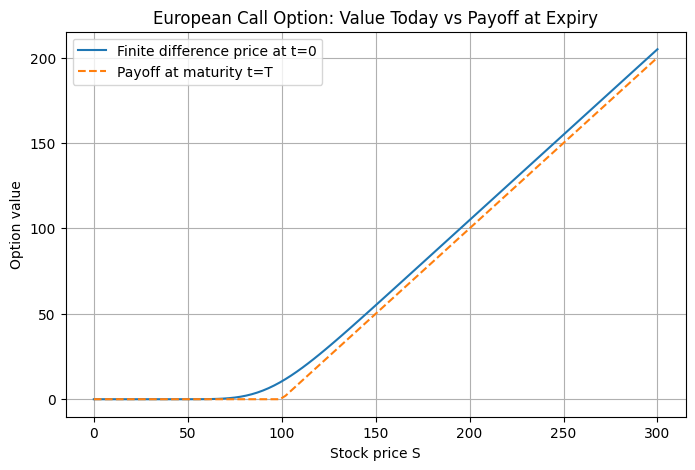

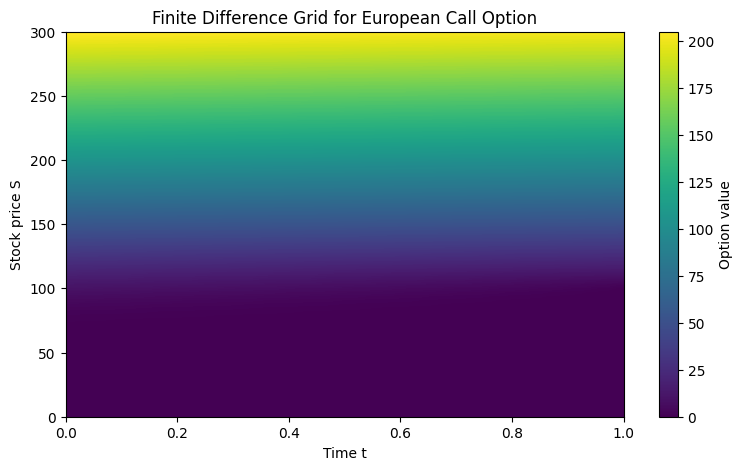


Black-Scholes exact price: 10.4506
Finite difference price: 10.4658
Absolute error: 0.0152


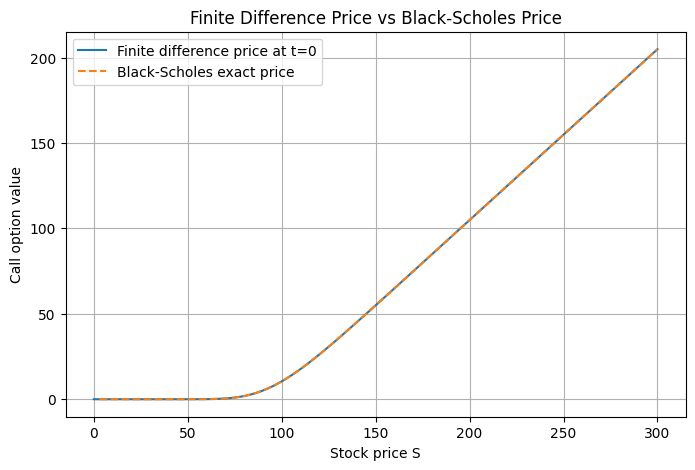


Finite difference Delta at S0 = 100 : 0.6171
Finite difference Gamma at S0 = 100 : 0.019283


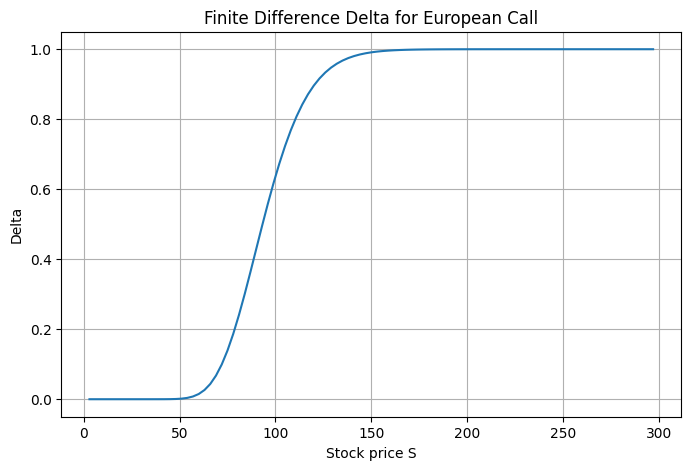

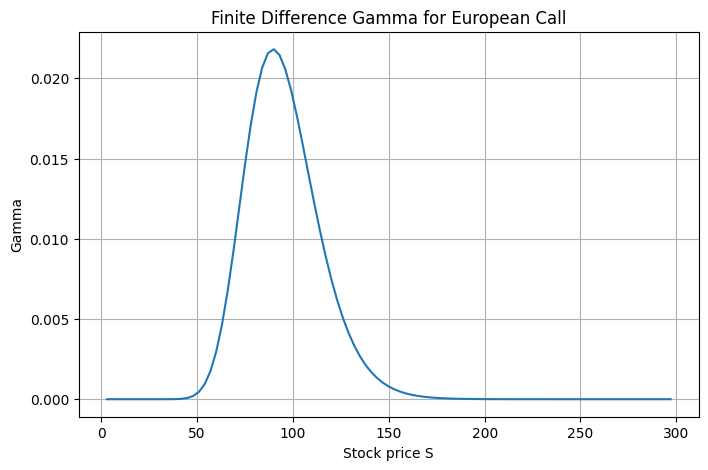


Convergence table:
     M      N    dS       dt  FDM Price   BS Price  Absolute Error
0   20   2000  15.0  0.00050  10.881430  10.450584        0.430847
1   50   5000   6.0  0.00020  10.513869  10.450584        0.063286
2  100  10000   3.0  0.00010  10.465814  10.450584        0.015230
3  200  20000   1.5  0.00005  10.454484  10.450584        0.003901


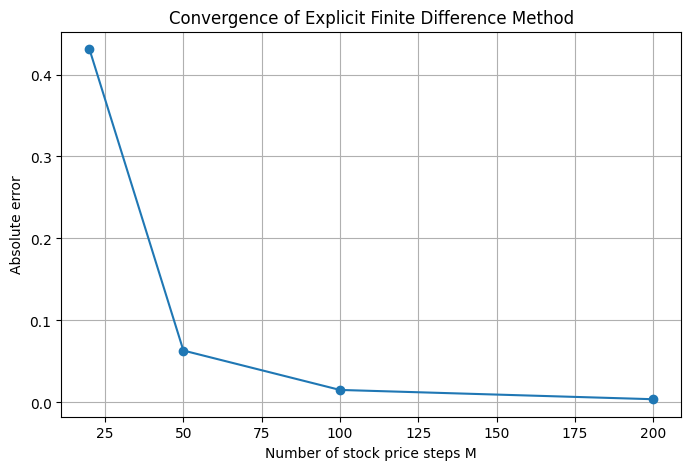

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# 1. Parameters
# -----------------------------

E = 100          # strike price
S0 = 100         # current stock price we care about

S_max = 300     # maximum stock price in the grid
M = 100         # number of stock price steps, larger = smaller dS

T = 1           # time to maturity, in years
N = 10000       # number of time steps, larger = smaller dt

r = 0.05        # risk-free interest rate
sigma = 0.2     # volatility

# -----------------------------
# 2. Step sizes
# -----------------------------

dS = S_max / M
dt = T / N

print("dS =", dS)
print("dt =", dt)

# -----------------------------
# 3. Stability check
# -----------------------------

# Approximate stability condition for explicit Black-Scholes FDM:
# dt < 1 / (sigma^2 * M^2)

stability_limit = 1 / (sigma**2 * M**2)

print("\nApproximate stability limit:", stability_limit)

if dt < stability_limit:
    print("Stability condition satisfied.")
else:
    print("Warning: dt may be too large. The explicit scheme may be unstable.")

# -----------------------------
# 4. Create stock and time grids
# -----------------------------

S = np.linspace(0, S_max, M + 1)
t = np.linspace(0, T, N + 1)

# V[i, k] approximates the option value at stock price S_i and time t_k
V = np.zeros((M + 1, N + 1))

# -----------------------------
# 5. Final condition at maturity
# -----------------------------

# European call payoff: C(S,T) = max(S - E, 0)
V[:, N] = np.maximum(S - E, 0)

# -----------------------------
# 6. Boundary conditions
# -----------------------------

# Boundary at S = 0
V[0, :] = 0

# Boundary at S = S_max
V[M, :] = S_max - E * np.exp(-r * (T - t))

# -----------------------------
# 7. Explicit finite difference method
# -----------------------------

# Work backwards in time
for k in range(N - 1, -1, -1):
    for i in range(1, M):
        a = 0.5 * dt * (sigma**2 * i**2 - r * i)
        b = 1 - dt * (sigma**2 * i**2 + r)
        c = 0.5 * dt * (sigma**2 * i**2 + r * i)

        V[i, k] = (
            a * V[i - 1, k + 1]
            + b * V[i, k + 1]
            + c * V[i + 1, k + 1]
        )

# -----------------------------
# 8. Display a readable table
# -----------------------------

# Choose selected time columns to display
selected_columns = [0, int(0.2*N), int(0.4*N), int(0.6*N), int(0.8*N), N]

# Choose selected stock rows to display
# Reversed order so that S=300 appears at the top and S=0 at the bottom,
# matching the stock-price axis in the presentation grid.
selected_rows = list(range(M, -1, -10))

V_table = pd.DataFrame(
    V[np.ix_(selected_rows, selected_columns)],
    index=[f"S={S[i]:.0f}" for i in selected_rows],
    columns=[f"t={t[k]:.1f}" for k in selected_columns]
)

V_table = V_table.round(4)

print("\nFinite difference grid table in intervals of S=30 and t=0.2:")
print(V_table)

# -----------------------------
# 9. Extract the option price today
# -----------------------------


price_today = np.interp(S0, S, V[:, 0])

print("\nFinite difference price at S0 =", S0, ":", round(price_today, 4))

i0 = int(S0 / dS) # To use later for the greeks


# -----------------------------
# 10. Plot option value today vs payoff at maturity
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(S, V[:, 0], label="Finite difference price at t=0")
plt.plot(S, V[:, N], label="Payoff at maturity t=T", linestyle="--")

plt.xlabel("Stock price S")
plt.ylabel("Option value")
plt.title("European Call Option: Value Today vs Payoff at Expiry")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 11. Heatmap of the grid
# -----------------------------

plt.figure(figsize=(9, 5))

plt.imshow(V, aspect="auto", origin="lower", extent=[0, T, 0, S_max])
plt.colorbar(label="Option value")

plt.xlabel("Time t")
plt.ylabel("Stock price S")
plt.title("Finite Difference Grid for European Call Option")
plt.show()

# -----------------------------
# 12. Black-Scholes exact formula
# -----------------------------

def black_scholes_call(S0, E, T, r, sigma):
    d1 = (np.log(S0 / E) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S0 * norm.cdf(d1) - E * np.exp(-r * T) * norm.cdf(d2)
    return call_price

bs_price = black_scholes_call(S0, E, T, r, sigma)

print("\nBlack-Scholes exact price:", round(bs_price, 4))
print("Finite difference price:", round(price_today, 4))
print("Absolute error:", round(abs(price_today - bs_price), 4))

# -----------------------------
# 13. Compare finite difference curve with Black-Scholes curve
# -----------------------------

# Avoid S = 0 in Black-Scholes because log(0) is undefined
S_positive = S[1:]

bs_curve = np.array([
    black_scholes_call(s, E, T, r, sigma)
    for s in S_positive
])

plt.figure(figsize=(8, 5))

plt.plot(S, V[:, 0], label="Finite difference price at t=0")
plt.plot(S_positive, bs_curve, label="Black-Scholes exact price", linestyle="--")

plt.xlabel("Stock price S")
plt.ylabel("Call option value")
plt.title("Finite Difference Price vs Black-Scholes Price")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 14. Greeks from the finite difference grid
# -----------------------------

# Delta and Gamma at S0, t=0
delta_fd = (V[i0 + 1, 0] - V[i0 - 1, 0]) / (2 * dS)

gamma_fd = (V[i0 + 1, 0] - 2 * V[i0, 0] + V[i0 - 1, 0]) / (dS ** 2)

print("\nFinite difference Delta at S0 =", S0, ":", round(delta_fd, 4))
print("Finite difference Gamma at S0 =", S0, ":", round(gamma_fd, 6))

# Delta curve across stock prices at t=0
delta_curve = np.zeros(M + 1)
delta_curve[1:M] = (V[2:M+1, 0] - V[0:M-1, 0]) / (2 * dS)

plt.figure(figsize=(8, 5))
plt.plot(S[1:M], delta_curve[1:M])

plt.xlabel("Stock price S")
plt.ylabel("Delta")
plt.title("Finite Difference Delta for European Call")
plt.grid(True)
plt.show()

# Gamma curve across stock prices at t=0
gamma_curve = np.zeros(M + 1)
gamma_curve[1:M] = (V[2:M+1, 0] - 2 * V[1:M, 0] + V[0:M-1, 0]) / (dS ** 2)

plt.figure(figsize=(8, 5))
plt.plot(S[1:M], gamma_curve[1:M])

plt.xlabel("Stock price S")
plt.ylabel("Gamma")
plt.title("Finite Difference Gamma for European Call")
plt.grid(True)
plt.show()

# -----------------------------
# 15. Function for convergence table and later real-stock use
# -----------------------------

def finite_difference_call_price(S0, E, S_max, M, T, N, r, sigma, return_grid=False):
    """
    Computes the European call option price using the explicit finite difference method.

    If return_grid=True, also returns the stock grid, time grid and full option value grid.
    """

    dS = S_max / M
    dt = T / N

    S = np.linspace(0, S_max, M + 1)
    t = np.linspace(0, T, N + 1)

    V = np.zeros((M + 1, N + 1))

    # Final condition at maturity
    V[:, N] = np.maximum(S - E, 0)

    # Boundary conditions
    V[0, :] = 0
    V[M, :] = S_max - E * np.exp(-r * (T - t))

    # Explicit finite difference method
    for k in range(N - 1, -1, -1):
        for i in range(1, M):
            a = 0.5 * dt * (sigma**2 * i**2 - r * i)
            b = 1 - dt * (sigma**2 * i**2 + r)
            c = 0.5 * dt * (sigma**2 * i**2 + r * i)

            V[i, k] = (
                a * V[i - 1, k + 1]
                + b * V[i, k + 1]
                + c * V[i + 1, k + 1]
            )

    # Interpolate to get price at S0
    price = np.interp(S0, S, V[:, 0])

    if return_grid:
        return price, dS, dt, S, t, V

    return price, dS, dt

# -----------------------------
# 16. Convergence table for real-data application
# -----------------------------

grid_sizes = [
    (20, 2000),
    (50, 5000),
    (100, 10000),
    (200, 20000)
]

bs_price = black_scholes_call(S0, E, T, r, sigma)

results = []

for M_test, N_test in grid_sizes:
    fd_price, dS_test, dt_test = finite_difference_call_price(
        S0, E, S_max, M_test, T, N_test, r, sigma
    )

    error = abs(fd_price - bs_price)

    stability_limit_test = 1 / (sigma**2 * M_test**2)
    stable = dt_test < stability_limit_test

    results.append([
        M_test,
        N_test,
        dS_test,
        dt_test,

        fd_price,
        bs_price,
        error
    ])

convergence_table = pd.DataFrame(
    results,
    columns=[
        "M",
        "N",
        "dS",
        "dt",

        "FDM Price",
        "BS Price",
        "Absolute Error"
    ]
)

convergence_table = convergence_table.round(6)

print("\nConvergence table:")
print(convergence_table)

# -----------------------------
# 17. Plot convergence error
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(convergence_table["M"], convergence_table["Absolute Error"], marker="o")

plt.xlabel("Number of stock price steps M")
plt.ylabel("Absolute error")
plt.title("Convergence of Explicit Finite Difference Method")
plt.grid(True)
plt.show()


Volatility sensitivity table:
   Volatility  Finite Difference Price  Black-Scholes Price  Absolute Error
0         0.1                 6.825329             6.804958        0.020372
1         0.2                10.465814            10.450584        0.015230
2         0.3                14.242283            14.231255        0.011028
3         0.4                18.031627            18.022951        0.008676
4         0.5                21.799799            21.792604        0.007195


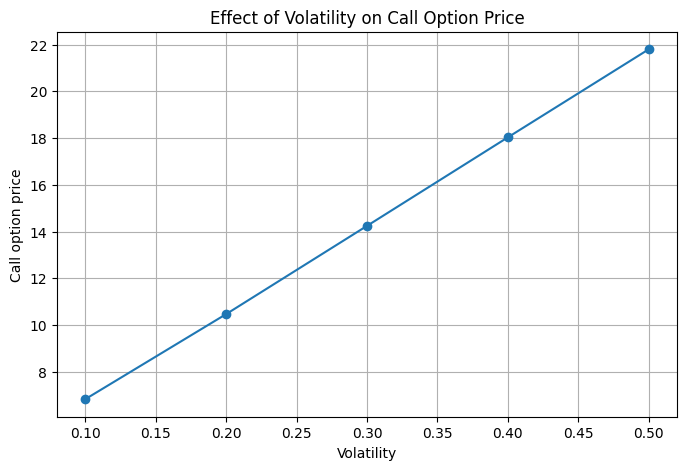

In [5]:
# -----------------------------
# 18. Volatility sensitivity analysis
# -----------------------------

vol_values = [0.10, 0.20, 0.30, 0.40, 0.50]

vol_results = []

for sigma_test in vol_values:
    fd_price, dS_test, dt_test = finite_difference_call_price(
        S0, E, S_max, M, T, N, r, sigma_test
    )

    bs_price_test = black_scholes_call(S0, E, T, r, sigma_test)

    vol_results.append([
        sigma_test,
        fd_price,
        bs_price_test,
        abs(fd_price - bs_price_test)
    ])

vol_table = pd.DataFrame(
    vol_results,
    columns=[
        "Volatility",
        "Finite Difference Price",
        "Black-Scholes Price",
        "Absolute Error"
    ]
)

vol_table = vol_table.round(6)

print("\nVolatility sensitivity table:")
print(vol_table)

plt.figure(figsize=(8, 5))
plt.plot(vol_table["Volatility"], vol_table["Finite Difference Price"], marker="o")
plt.xlabel("Volatility")
plt.ylabel("Call option price")
plt.title("Effect of Volatility on Call Option Price")
plt.grid(True)
plt.show()

In [6]:
# -----------------------------
# 19. Real stock application with historical volatility
# -----------------------------

import yfinance as yf

ticker = "NVDA"

# Download one year of daily prices from Yahoo Finance
data = yf.download(ticker, period="1y", auto_adjust=True)

# Use closing prices
prices = data["Close"].dropna()

# Current stock price
S0_real = prices.iloc[-1].item()

# Daily log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# Historical volatility estimates over different windows
vol_30 = (log_returns.tail(30).std() * np.sqrt(252)).item()
vol_90 = (log_returns.tail(90).std() * np.sqrt(252)).item()
vol_1y = (log_returns.std() * np.sqrt(252)).item()

print("Ticker:", ticker)
print("Current stock price S0:", round(S0_real, 4))
print("30-day historical volatility:", round(vol_30, 4))
print("90-day historical volatility:", round(vol_90, 4))
print("1-year historical volatility:", round(vol_1y, 4))

/Users/nikolasathinodorou/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed

Ticker: NVDA
Current stock price S0: 230.86
30-day historical volatility: 0.3843
90-day historical volatility: 0.3941
1-year historical volatility: 0.3768


In [7]:
# -----------------------------
# 20. Price real stock option using different volatility estimates
# -----------------------------

# Choose realistic option inputs
E_real = round(S0_real / 5) * 5     # strike rounded to nearest 5
T_real = 30 / 365                  # 30 days to maturity
r_real = 0.0371                    # approximate 1-month US Treasury rate
S_max_real = 3 * S0_real           # large enough upper boundary

M_real = 200
N_real = 20000

vol_estimates = {
    "30-day vol": vol_30,
    "90-day vol": vol_90,
    "1-year vol": vol_1y
}

real_results = []

for label, sigma_real in vol_estimates.items():
    fd_price_real, dS_real, dt_real = finite_difference_call_price(
        S0_real,
        E_real,
        S_max_real,
        M_real,
        T_real,
        N_real,
        r_real,
        sigma_real
    )

    bs_price_real = black_scholes_call(
        S0_real,
        E_real,
        T_real,
        r_real,
        sigma_real
    )

    real_results.append([
        label,
        sigma_real,
        fd_price_real,
        bs_price_real,
        abs(fd_price_real - bs_price_real)
    ])

real_vol_table = pd.DataFrame(
    real_results,
    columns=[
        "Volatility Estimate",
        "Historical Volatility",
        "Finite Difference Price",
        "Black-Scholes Price",
        "Absolute Error"
    ]
)

real_vol_table = real_vol_table.round(6)

print("\nReal stock option pricing using historical volatility:")
print("Ticker:", ticker)
print("S0:", round(S0_real, 4))
print("Strike E:", E_real)
print("Maturity T:", round(T_real, 4))
print("Risk-free rate r:", r_real)
print(real_vol_table)


Real stock option pricing using historical volatility:
Ticker: NVDA
S0: 230.86
Strike E: 230
Maturity T: 0.0822
Risk-free rate r: 0.0371
  Volatility Estimate  Historical Volatility  Finite Difference Price  \
0          30-day vol               0.384283                10.926952   
1          90-day vol               0.394097                11.183812   
2          1-year vol               0.376785                10.730710   

   Black-Scholes Price  Absolute Error  
0            10.906551        0.020402  
1            11.163913        0.019899  
2            10.709907        0.020803  


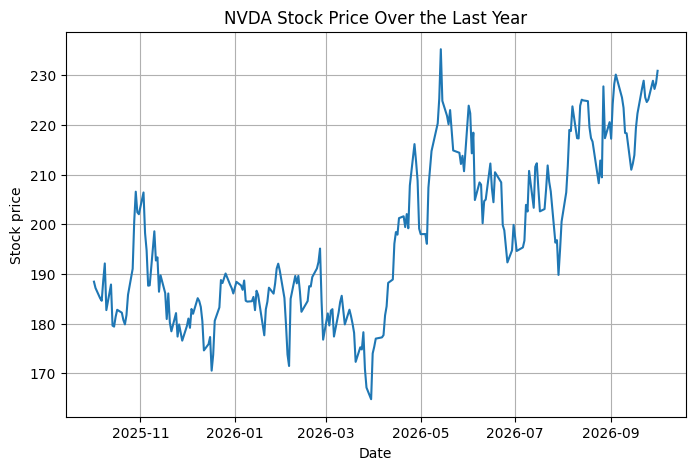

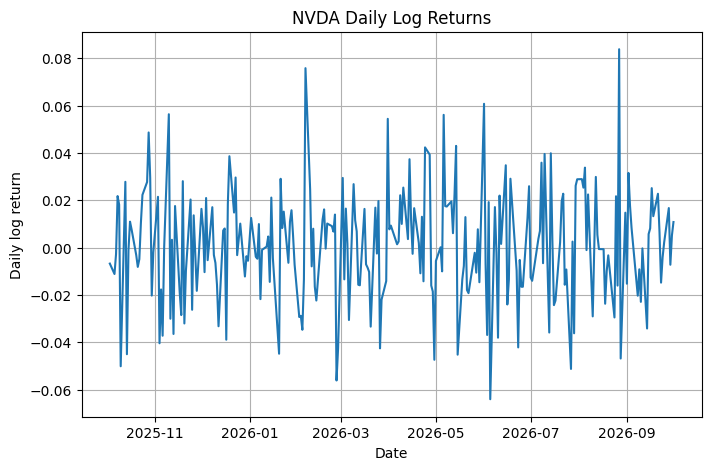

In [8]:
# -----------------------------
# 21. Plot historical stock price and daily log returns
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(prices)
plt.xlabel("Date")
plt.ylabel("Stock price")
plt.title(f"{ticker} Stock Price Over the Last Year")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(log_returns)
plt.xlabel("Date")
plt.ylabel("Daily log return")
plt.title(f"{ticker} Daily Log Returns")
plt.grid(True)
plt.show()

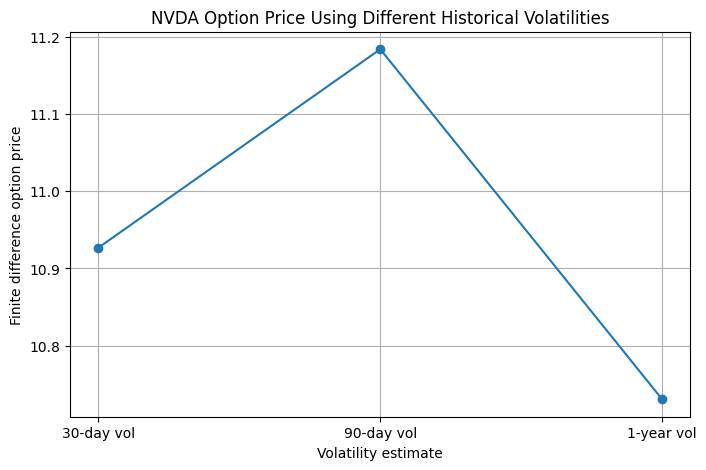

In [9]:
# -----------------------------
# 21b. Plot option price under different volatility estimates
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    real_vol_table["Volatility Estimate"],
    real_vol_table["Finite Difference Price"],
    marker="o"
)

plt.xlabel("Volatility estimate")
plt.ylabel("Finite difference option price")
plt.title(f"{ticker} Option Price Using Different Historical Volatilities")
plt.grid(True)
plt.show()

In [10]:
# -----------------------------
# 22. Effect of maturity on real stock option price
# with maturity-matched risk-free rates
# -----------------------------

maturities = {
    "1 month": 30 / 365,
    "3 months": 90 / 365,
    "6 months": 180 / 365,
    "1 year": 1
}

# Approximate US Treasury rates matching each maturity
# These can be updated using current market data if needed
risk_free_rates = {
    "1 month": 0.0371,
    "3 months": 0.0375,
    "6 months": 0.0380,
    "1 year": 0.0385
}

# Keep volatility fixed so we isolate the effect of maturity
sigma_chosen = vol_90

maturity_results = []

for maturity_label, T_value in maturities.items():

    r_value = risk_free_rates[maturity_label]

    fd_price, dS, dt = finite_difference_call_price(
        S0_real,
        E_real,
        S_max_real,
        M_real,
        T_value,
        N_real,
        r_value,
        sigma_chosen
    )

    bs_price = black_scholes_call(
        S0_real,
        E_real,
        T_value,
        r_value,
        sigma_chosen
    )

    maturity_results.append([
        maturity_label,
        T_value,
        r_value,
        sigma_chosen,
        fd_price,
        bs_price,
        abs(fd_price - bs_price)
    ])

maturity_table = pd.DataFrame(
    maturity_results,
    columns=[
        "Maturity",
        "T",
        "Risk-free Rate",
        "Volatility Used",
        "Finite Difference Price",
        "Black-Scholes Price",
        "Absolute Error"
    ]
)

maturity_table = maturity_table.round(6)

print("\nEffect of maturity on real stock option price:")
print("Ticker:", ticker)
print("S0:", round(S0_real, 4))
print("Strike E:", E_real)
print("Volatility used (90-day Volatility ):", round(sigma_chosen, 4))
print(maturity_table)


Effect of maturity on real stock option price:
Ticker: NVDA
S0: 230.86
Strike E: 230
Volatility used (90-day Volatility ): 0.3941
   Maturity         T  Risk-free Rate  Volatility Used  \
0   1 month  0.082192          0.0371         0.394097   
1  3 months  0.246575          0.0375         0.394097   
2  6 months  0.493151          0.0380         0.394097   
3    1 year  1.000000          0.0385         0.394097   

   Finite Difference Price  Black-Scholes Price  Absolute Error  
0                11.183812            11.163913        0.019899  
1                19.417823            19.406285        0.011538  
2                27.780987            27.772764        0.008223  
3                40.296243            40.290365        0.005878  


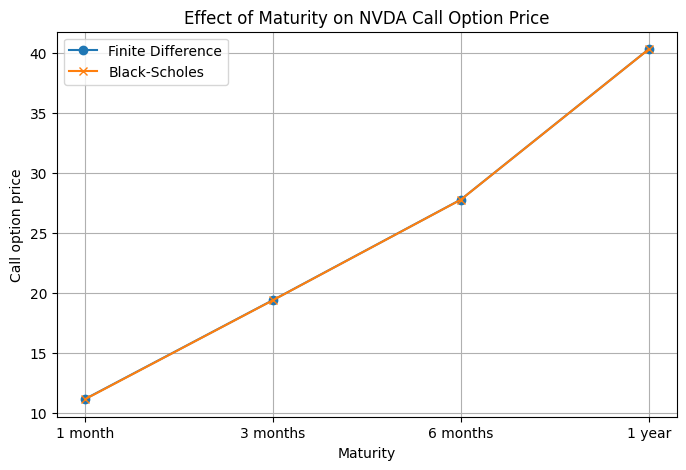

In [11]:
# -----------------------------
# 23. Plot effect of maturity with maturity-matched rates
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    maturity_table["Maturity"],
    maturity_table["Finite Difference Price"],
    marker="o",
    label="Finite Difference"
)

plt.plot(
    maturity_table["Maturity"],
    maturity_table["Black-Scholes Price"],
    marker="x",
    label="Black-Scholes"
)

plt.xlabel("Maturity")
plt.ylabel("Call option price")
plt.title(f"Effect of Maturity on {ticker} Call Option Price")
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Comparison across different stocks:
  Ticker          S0  Strike E  90-day Historical Volatility  \
0   AAPL  330.320007       330                      0.295047   
1   MSFT  512.799988       515                      0.394456   
2   NVDA  230.860001       230                      0.394097   
3   TSLA  354.109985       355                      0.529088   
4    JPM  333.329987       335                      0.206931   

   Finite Difference Price  Black-Scholes Price  Absolute Error  FD Price / S0  
0                11.833377            11.796050        0.037326       0.035824  
1                22.826479            22.822339        0.004140       0.044513  
2                11.183812            11.163912        0.019899       0.048444  
3                21.509643            21.497694        0.011949       0.060743  
4                 7.568561             7.574826        0.006265       0.022706  


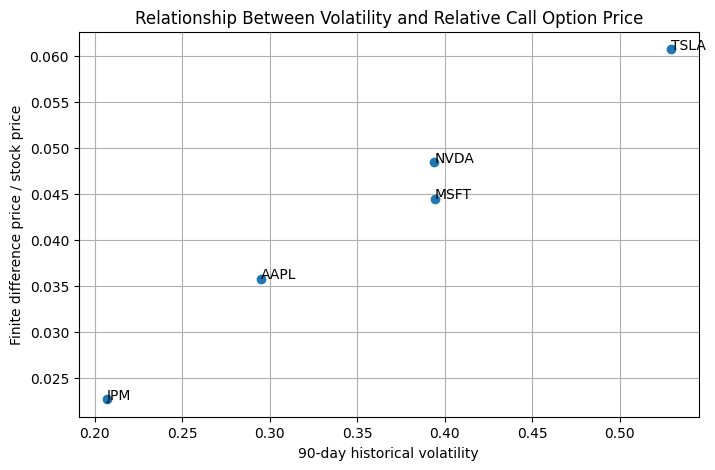

In [12]:
# -----------------------------
# 24. Comparing different real stocks (optional)
# -----------------------------

tickers = ["AAPL", "MSFT", "NVDA", "TSLA", "JPM"]

T_compare = 30 / 365      # 1-month maturity
r_compare = r_real        # constant risk-free rate for simplicity

stock_results = []

for ticker_name in tickers:

    # Download one year of daily prices
    data_stock = yf.download(ticker_name, period="1y", auto_adjust=True)
    prices_stock = data_stock["Close"].dropna()

    # Current stock price
    S0_stock = prices_stock.iloc[-1].item()

    # Daily log returns
    log_returns_stock = np.log(prices_stock / prices_stock.shift(1)).dropna()

    # 90-day historical volatility
    vol_stock = (log_returns_stock.tail(90).std() * np.sqrt(252)).item()

    # At-the-money strike, rounded to nearest 5
    E_stock = round(S0_stock / 5) * 5

    # Upper boundary
    S_max_stock = 3 * S0_stock

    # Finite difference price
    fd_price_stock, dS_stock, dt_stock = finite_difference_call_price(
        S0_stock,
        E_stock,
        S_max_stock,
        M_real,
        T_compare,
        N_real,
        r_compare,
        vol_stock
    )

    # Black-Scholes price
    bs_price_stock = black_scholes_call(
        S0_stock,
        E_stock,
        T_compare,
        r_compare,
        vol_stock
    )

    # Option price as a percentage of the stock price
    fd_price_percent = fd_price_stock / S0_stock

    stock_results.append([
        ticker_name,
        S0_stock,
        E_stock,
        vol_stock,
        fd_price_stock,
        bs_price_stock,
        abs(fd_price_stock - bs_price_stock),
        fd_price_percent
    ])

stock_comparison_table = pd.DataFrame(
    stock_results,
    columns=[
        "Ticker",
        "S0",
        "Strike E",
        "90-day Historical Volatility",
        "Finite Difference Price",
        "Black-Scholes Price",
        "Absolute Error",
        "FD Price / S0"
    ]
)

stock_comparison_table = stock_comparison_table.round(6)

print("\nComparison across different stocks:")
print(stock_comparison_table)
# -----------------------------
# 25. Plot volatility against relative option price
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    stock_comparison_table["90-day Historical Volatility"],
    stock_comparison_table["FD Price / S0"]
)

for i in range(len(stock_comparison_table)):
    plt.text(
        stock_comparison_table["90-day Historical Volatility"].iloc[i],
        stock_comparison_table["FD Price / S0"].iloc[i],
        stock_comparison_table["Ticker"].iloc[i]
    )

plt.xlabel("90-day historical volatility")
plt.ylabel("Finite difference price / stock price")
plt.title("Relationship Between Volatility and Relative Call Option Price")
plt.grid(True)
plt.show()

In [13]:
# -----------------------------
# 26. Convergence analysis of selected ticker
# -----------------------------

M_values = [50, 100, 200, 400]
N_values = [5000, 10000, 20000, 40000]

convergence_results = []

for M_test, N_test in zip(M_values, N_values):

    fd_price, dS, dt = finite_difference_call_price(
        S0_real,
        E_real,
        S_max_real,
        M_test,
        T_real,
        N_test,
        r_real,
        vol_90
    )

    bs_price = black_scholes_call(
        S0_real,
        E_real,
        T_real,
        r_real,
        vol_90
    )

    convergence_results.append([
        M_test,
        N_test,
        dS,
        dt,
        fd_price,
        bs_price,
        abs(fd_price - bs_price)
    ])

convergence_table = pd.DataFrame(
    convergence_results,
    columns=[
        "M",
        "N",
        "dS",
        "dt",
        "Finite Difference Price",
        "Black-Scholes Price",
        "Absolute Error"
    ]
)

convergence_table = convergence_table.round(8)

print("\nConvergence analysis:")
print(convergence_table)


Convergence analysis:
     M      N        dS        dt  Finite Difference Price  \
0   50   5000  13.85160  0.000016                11.485552   
1  100  10000   6.92580  0.000008                11.213636   
2  200  20000   3.46290  0.000004                11.183812   
3  400  40000   1.73145  0.000002                11.166436   

   Black-Scholes Price  Absolute Error  
0            11.163913        0.321639  
1            11.163913        0.049723  
2            11.163913        0.019899  
3            11.163913        0.002524  


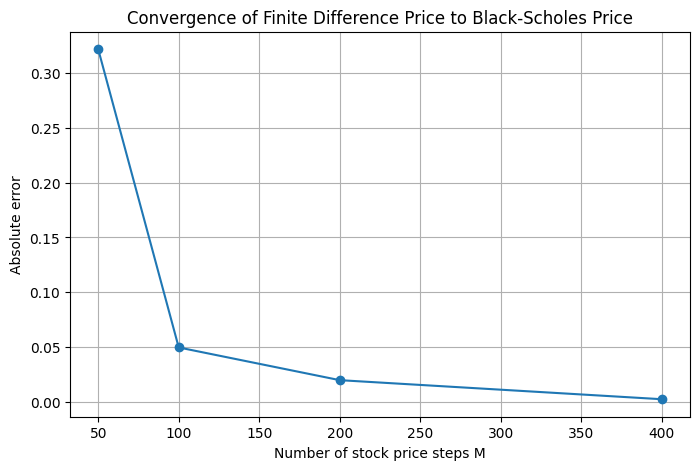

In [14]:
# -----------------------------
# 27. Plot convergence error
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    convergence_table["M"],
    convergence_table["Absolute Error"],
    marker="o"
)

plt.xlabel("Number of stock price steps M")
plt.ylabel("Absolute error")
plt.title("Convergence of Finite Difference Price to Black-Scholes Price")
plt.grid(True)
plt.show()


In [15]:
# -----------------------------
# 28. Stability check for real-life application
# -----------------------------

def explicit_stability_check(sigma, M, T, N):
    dt = T / N
    stability_value = sigma**2 * M**2 * dt

    stable = stability_value <= 1

    return stability_value, stable


# Check stability for the real-life application
stability_value, stable = explicit_stability_check(
    sigma=vol_90,
    M=M_real,
    T=T_real,
    N=N_real
)

print("Stability check for real-life", ticker, "application")
print("sigma:", round(vol_90, 6))
print("M:", M_real)
print("T:", round(T_real, 6))
print("N:", N_real)
print("dt:", round(T_real / N_real, 10))
print("sigma^2 * M^2 * dt:", round(stability_value, 6))

if stable:
    print("The explicit finite difference scheme satisfies the stability condition.")
else:
    print("Warning: the explicit finite difference scheme may be unstable.")

Stability check for real-life NVDA application
sigma: 0.394097
M: 200
T: 0.082192
N: 20000
dt: 4.1096e-06
sigma^2 * M^2 * dt: 0.025531
The explicit finite difference scheme satisfies the stability condition.


# Part 2: Implied volatility

Part 1 priced options with **historical** volatility (how much the stock moved in the past).
Part 2 asks: *how far are those prices from what the market actually charges, and where?*

- **29.** Upgraded FDM pricer: calls and puts, dividends, faster
- **30.** Download the real option chain (S&P 500 index options)
- **31.** Implied volatility solver (Newton, with Brent as fallback) + test
- **32.** Implied volatility across strikes and maturities: the skew
- **33.** Main result: FDM price with historical vol vs market price, strike by strike
- **34.** Hedging consequence: delta of a crash put under historical vs implied vol

In [16]:
# -----------------------------
# 29. Upgraded pricer: calls AND puts, dividends, faster, automatic stability
# -----------------------------
# Same explicit scheme as section 7, with four changes:
#   1. option="call" or "put" (puts are needed for the crash-protection analysis)
#   2. q = dividend yield (the S&P 500 pays dividends; q=0 gives back the original model)
#   3. the loop over stock prices is done with numpy in one line (~100x faster)
#   4. N is automatically increased if the stability condition would fail

def black_scholes_price(S0, E, T, r, sigma, option="call", q=0.0):
    d1 = (np.log(S0 / E) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option == "call":
        return S0 * np.exp(-q * T) * norm.cdf(d1) - E * np.exp(-r * T) * norm.cdf(d2)
    else:
        return E * np.exp(-r * T) * norm.cdf(-d2) - S0 * np.exp(-q * T) * norm.cdf(-d1)


def black_scholes_vega(S0, E, T, r, sigma, q=0.0):
    # How much the price changes when volatility changes (same for calls and puts)
    d1 = (np.log(S0 / E) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S0 * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)


def finite_difference_price(S0, E, S_max, M, T, N, r, sigma, option="call", q=0.0,
                            return_grid=False):
    dS = S_max / M

    # Stability: need dt < 1 / (sigma^2 * M^2), so N must be at least sigma^2 * M^2 * T
    min_N = int(np.ceil(1.1 * sigma**2 * M**2 * T))
    N = max(N, min_N)
    dt = T / N

    S = np.linspace(0, S_max, M + 1)
    t = np.linspace(0, T, N + 1)

    # Payoff at expiry and the value at the two edges of the grid
    # (tau = time left until expiry)
    if option == "call":
        payoff = np.maximum(S - E, 0)
        low_edge = lambda tau: 0.0
        high_edge = lambda tau: S_max * np.exp(-q * tau) - E * np.exp(-r * tau)
    else:
        payoff = np.maximum(E - S, 0)
        low_edge = lambda tau: E * np.exp(-r * tau)
        high_edge = lambda tau: 0.0

    # Same coefficients as section 7 (with r replaced by r - q in the drift term)
    i = np.arange(1, M)
    a = 0.5 * dt * (sigma**2 * i**2 - (r - q) * i)
    b = 1 - dt * (sigma**2 * i**2 + r)
    c = 0.5 * dt * (sigma**2 * i**2 + (r - q) * i)

    # Only keep the full grid if it is asked for (it can be very large)
    if return_grid:
        V = np.zeros((M + 1, N + 1))
        V[:, N] = payoff

    v = payoff.copy()
    for k in range(N - 1, -1, -1):
        tau = T - t[k]
        v_new = np.empty(M + 1)
        v_new[1:M] = a * v[0:M-1] + b * v[1:M] + c * v[2:M+1]
        v_new[0] = low_edge(tau)
        v_new[M] = high_edge(tau)
        v = v_new
        if return_grid:
            V[:, k] = v

    price = np.interp(S0, S, v)

    if return_grid:
        return price, dS, dt, S, t, V
    return price, dS, dt


# Keep the old names working so sections 15-28 still run unchanged
def black_scholes_call(S0, E, T, r, sigma):
    return black_scholes_price(S0, E, T, r, sigma, "call")

def finite_difference_call_price(S0, E, S_max, M, T, N, r, sigma, return_grid=False):
    return finite_difference_price(S0, E, S_max, M, T, N, r, sigma, "call",
                                   return_grid=return_grid)


# Check: the call should match section 9 (10.4658); the put should match Black-Scholes
fd_call, _, _ = finite_difference_price(100, 100, 300, 100, 1, 10000, 0.05, 0.2, "call")
fd_put, _, _ = finite_difference_price(100, 100, 300, 100, 1, 10000, 0.05, 0.2, "put")
fd_put_q, _, _ = finite_difference_price(100, 100, 300, 100, 1, 10000, 0.05, 0.2, "put", q=0.02)

print("Call          FDM:", round(fd_call, 4), "  BS:", round(black_scholes_price(100, 100, 1, 0.05, 0.2, "call"), 4))
print("Put           FDM:", round(fd_put, 4), "  BS:", round(black_scholes_price(100, 100, 1, 0.05, 0.2, "put"), 4))
print("Put, q = 2%   FDM:", round(fd_put_q, 4), "  BS:", round(black_scholes_price(100, 100, 1, 0.05, 0.2, "put", 0.02), 4))


Call          FDM: 10.4658   BS: 10.4506
Put           FDM: 5.5887   BS: 5.5735
Put, q = 2%   FDM: 6.3463   BS: 6.3301


In [17]:
# -----------------------------
# 30. Download the option chain (market prices)
# -----------------------------
# Best run during US market hours (14:30-21:00 London time). Outside those hours
# Yahoo often shows bid = 0 / ask = 0, and those options get filtered out.

import yfinance as yf

OPTION_TICKER = "^SPX"     # S&P 500 index options (European). Try "NVDA" for comparison
PRICE_TICKER = "^GSPC"     # S&P 500 price history. Use the same as above for a stock, e.g. "NVDA"

TARGET_DAYS = [30, 60, 90, 180]    # maturities we want (closest available expiries are used)
MONEYNESS_RANGE = (0.70, 1.30)     # keep strikes between 70% and 130% of today's price

opt = yf.Ticker(OPTION_TICKER)

# --- Today's price and historical volatility (same method as section 19) ---
hist = yf.Ticker(PRICE_TICKER).history(period="1y")["Close"].dropna()
S0_mkt = float(hist.iloc[-1])
log_ret = np.log(hist / hist.shift(1)).dropna()

hist_vols = {
    "30-day": float(log_ret.tail(30).std() * np.sqrt(252)),
    "90-day": float(log_ret.tail(90).std() * np.sqrt(252)),
    "1-year": float(log_ret.std() * np.sqrt(252)),
}
sigma_hist = hist_vols["90-day"]    # the historical vol used for pricing, as in section 22

# --- Risk-free rate: 13-week US Treasury bill yield (^IRX is quoted in percent) ---
try:
    r_mkt = float(yf.Ticker("^IRX").history(period="5d")["Close"].dropna().iloc[-1]) / 100
except Exception:
    r_mkt = 0.0371    # fallback: the rate used in section 20
    print("Could not download the T-bill rate, using", r_mkt)

# --- Pick the expiries closest to the target maturities ---
today = pd.Timestamp.today().normalize()
expiries = pd.to_datetime(list(opt.options))
days_left = np.array([(e - today).days for e in expiries])

chosen = []
for target in TARGET_DAYS:
    j = int(np.argmin(np.abs(days_left - target)))
    if days_left[j] >= 7 and expiries[j] not in chosen:
        chosen.append(expiries[j])

# --- Download calls and puts for each chosen expiry and clean them ---
rows = []
for expiry in chosen:
    chain = opt.option_chain(expiry.strftime("%Y-%m-%d"))
    T_exp = (expiry - today).days / 365

    for option_type, df in [("call", chain.calls), ("put", chain.puts)]:
        df = df[["strike", "bid", "ask", "volume", "openInterest"]].copy()
        df["type"] = option_type
        df["expiry"] = expiry
        df["T"] = T_exp
        rows.append(df)

chain_df = pd.concat(rows, ignore_index=True)

# Cleaning:
#  - need a real bid and ask (both above zero, ask above bid)
#  - use the mid-point between bid and ask as "the market price"
#  - drop spreads wider than half the price (too unreliable)
#  - keep strikes within the moneyness range
chain_df = chain_df[(chain_df["bid"] > 0) & (chain_df["ask"] > chain_df["bid"])]
chain_df["mid"] = (chain_df["bid"] + chain_df["ask"]) / 2
chain_df = chain_df[(chain_df["ask"] - chain_df["bid"]) / chain_df["mid"] < 0.5]
chain_df["moneyness"] = chain_df["strike"] / S0_mkt
chain_df = chain_df[chain_df["moneyness"].between(*MONEYNESS_RANGE)].reset_index(drop=True)

print("Underlying:", OPTION_TICKER, "  price today:", round(S0_mkt, 2))
print("Risk-free rate:", round(r_mkt, 4))
print("Historical volatilities:", {k: round(v, 4) for k, v in hist_vols.items()})
print("\nOptions kept per expiry:")
print(chain_df.groupby(["expiry", "type"]).size().unstack())

if len(chain_df) < 20:
    print("\nWarning: very few options with live prices. "
          "Run this again during US market hours (14:30-21:00 London time).")


Underlying: ^SPX   price today: 7666.54
Risk-free rate: 0.0398
Historical volatilities: {'30-day': 0.0984, '90-day': 0.1245, '1-year': 0.1303}

Options kept per expiry:
type        call  put
expiry               
2026-10-30   335  409
2026-11-30   294  337
2026-12-31   418  510
2027-03-31   255  427


In [18]:
# -----------------------------
# 31. Implied volatility solver + sanity test
# -----------------------------
# We need the sigma that makes the Black-Scholes price equal the market price.
# Price increases with sigma, so there is exactly one answer.
#   Step 1: Newton's method (fast): sigma_new = sigma - (model price - market price) / vega
#   Step 2: if Newton misbehaves, Brent's method (slower but guaranteed) between 0.01% and 500%

from scipy.optimize import brentq

def implied_volatility(market_price, S0, E, T, r, option="call", q=0.0,
                       sigma_start=0.2, tol=1e-8, max_iter=50):

    disc_S = S0 * np.exp(-q * T)
    disc_E = E * np.exp(-r * T)

    # No volatility can explain a price outside these bounds (arbitrage limits)
    if option == "call":
        lower, upper = max(disc_S - disc_E, 0), disc_S
    else:
        lower, upper = max(disc_E - disc_S, 0), disc_E
    if not (lower < market_price < upper):
        return np.nan

    # Step 1: Newton
    sigma = sigma_start
    for _ in range(max_iter):
        diff = black_scholes_price(S0, E, T, r, sigma, option, q) - market_price
        if abs(diff) < tol:
            return sigma
        vega = black_scholes_vega(S0, E, T, r, sigma, q)
        if vega < 1e-10:
            break
        sigma_next = sigma - diff / vega
        if not (1e-4 < sigma_next < 5):
            break
        sigma = sigma_next

    # Step 2: Brent fallback
    f = lambda s: black_scholes_price(S0, E, T, r, s, option, q) - market_price
    try:
        return brentq(f, 1e-4, 5, xtol=tol)
    except ValueError:
        return np.nan


# --- Sanity test: price options at a KNOWN volatility, then check the solver recovers it ---
test_rows = []
for option_type in ["call", "put"]:
    for E_test in [70, 85, 100, 115, 130]:
        for sigma_true in [0.10, 0.25, 0.60]:
            # Skip options with no time value: their price is the same for any low
            # volatility, so no solver could recover it (vega is essentially zero)
            if black_scholes_vega(100, E_test, 0.25, 0.04, sigma_true, 0.015) < 1e-3:
                continue
            price = black_scholes_price(100, E_test, 0.25, 0.04, sigma_true, option_type, 0.015)
            sigma_found = implied_volatility(price, 100, E_test, 0.25, 0.04, option_type, 0.015)
            test_rows.append([option_type, E_test, sigma_true, sigma_found, abs(sigma_found - sigma_true)])

iv_test = pd.DataFrame(test_rows, columns=["Type", "Strike", "True vol", "Recovered vol", "Error"])
print("Implied volatility solver test (S0=100, T=0.25):")
print("Largest error:", iv_test["Error"].max())
print("Failures (NaN):", iv_test["Recovered vol"].isna().sum())
print(iv_test.head(6).round(8))


Implied volatility solver test (S0=100, T=0.25):
Largest error: 5.4208509750464096e-08
Failures (NaN): 0
   Type  Strike  True vol  Recovered vol         Error
0  call      70      0.25           0.25  0.000000e+00
1  call      70      0.60           0.60  0.000000e+00
2  call      85      0.10           0.10  5.000000e-08
3  call      85      0.25           0.25  0.000000e+00
4  call      85      0.60           0.60  0.000000e+00
5  call     100      0.10           0.10  0.000000e+00


Put-call parity check, strikes within 5% of today's price:
Average |call IV - put IV| = 0.0026

Dividend yield implied by parity for each expiry:
  2026-10-30  q = -0.0155
  2026-11-30  q = -0.0023
  2026-12-31  q = -0.001
  2027-03-31  q = 0.0


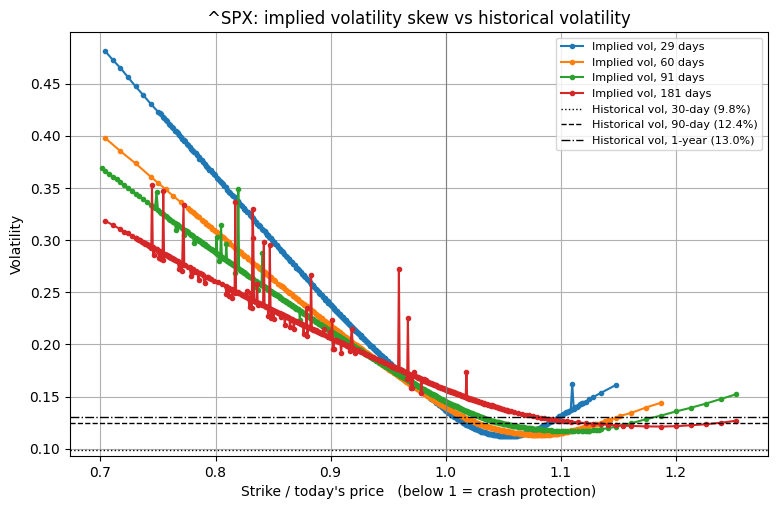


At-the-money implied vol by maturity (compare with 90-day historical vol = 0.1245):
   Days to expiry  Strike  At-the-money IV
0              29  7665.0           0.1372
1              60  7665.0           0.1397
2              91  7665.0           0.1455
3             181  7665.0           0.1570


In [19]:
# -----------------------------
# 32. Implied volatility across strikes and maturities (the skew)
# -----------------------------

# Step 1: dividend yield for each expiry, from put-call parity.
#   Call - Put = S0*exp(-qT) - E*exp(-rT)   (holds for any volatility)
#   => forward price F = E + exp(rT) * (Call - Put), and q = r - ln(F / S0) / T
#   We use the strikes closest to today's price, where both options trade actively.

q_by_expiry = {}
for expiry, group in chain_df.groupby("expiry"):
    T_exp = group["T"].iloc[0]
    calls = group[group["type"] == "call"].set_index("strike")["mid"]
    puts = group[group["type"] == "put"].set_index("strike")["mid"]
    both = calls.index.intersection(puts.index)
    near = both[np.argsort(np.abs(both - S0_mkt))[:5]]

    if len(near) == 0:
        q_by_expiry[expiry] = 0.0
        continue

    F = np.median(near + np.exp(r_mkt * T_exp) * (calls[near].values - puts[near].values))
    q_by_expiry[expiry] = float(np.clip(r_mkt - np.log(F / S0_mkt) / T_exp, -0.05, 0.10))

chain_df["q"] = chain_df["expiry"].map(q_by_expiry)

# Step 2: parity check. Call and put at the same strike should give the same implied vol.
chain_df["iv"] = [
    implied_volatility(row.mid, S0_mkt, row.strike, row.T, r_mkt, row.type, row.q)
    for row in chain_df.itertuples()
]

pairs = chain_df.pivot_table(index=["expiry", "strike"], columns="type", values="iv").dropna()
pairs = pairs[np.abs(pairs.index.get_level_values("strike") / S0_mkt - 1) < 0.05]
print("Put-call parity check, strikes within 5% of today's price:")
print("Average |call IV - put IV| =", round(float((pairs["call"] - pairs["put"]).abs().mean()), 4))

# Step 3: keep the out-of-the-money option at each strike
# (puts below today's price, calls above: these are the actively traded ones)
otm = chain_df[
    ((chain_df["type"] == "put") & (chain_df["strike"] < S0_mkt)) |
    ((chain_df["type"] == "call") & (chain_df["strike"] >= S0_mkt))
].dropna(subset=["iv"]).copy()

print("\nDividend yield implied by parity for each expiry:")
for expiry, q_val in q_by_expiry.items():
    print(" ", expiry.date(), " q =", round(q_val, 4))

# Step 4: plot the skew, one line per maturity, with historical vol as flat lines
plt.figure(figsize=(9, 5.5))

for expiry, group in otm.groupby("expiry"):
    group = group.sort_values("moneyness")
    days = int(round(group["T"].iloc[0] * 365))
    plt.plot(group["moneyness"], group["iv"], marker=".", label=f"Implied vol, {days} days")

styles = {"30-day": ":", "90-day": "--", "1-year": "-."}
for label, vol in hist_vols.items():
    plt.axhline(vol, color="black", linestyle=styles[label], linewidth=1,
                label=f"Historical vol, {label} ({vol:.1%})")

plt.axvline(1.0, color="grey", linewidth=0.8)
plt.xlabel("Strike / today's price   (below 1 = crash protection)")
plt.ylabel("Volatility")
plt.title(f"{OPTION_TICKER}: implied volatility skew vs historical volatility")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

# Step 5: term structure, implied vol at the money for each maturity
atm_rows = []
for expiry, group in otm.groupby("expiry"):
    j = (group["moneyness"] - 1).abs().idxmin()
    atm_rows.append([int(round(group.loc[j, "T"] * 365)), group.loc[j, "strike"], group.loc[j, "iv"]])

atm_table = pd.DataFrame(atm_rows, columns=["Days to expiry", "Strike", "At-the-money IV"])
print("\nAt-the-money implied vol by maturity (compare with 90-day historical vol "
      f"= {sigma_hist:.4f}):")
print(atm_table.round(4))


^SPX, 29-day options, 90-day historical vol = 12.45%
Largest FDM check error at implied vol: 0.302 %

FDM with historical vol vs market, selected strikes:
Type  Strike  Strike / S0  Market price  Implied vol  FDM price (hist vol)  Gap vs market (%)
 put  6520.0       0.8504         5.300       0.2980                0.0001           -99.9990
 put  6900.0       0.9000        10.450       0.2382                0.0619           -99.4081
 put  7285.0       0.9502        28.000       0.1835                6.3766           -77.2263
 put  7665.0       0.9998       101.400       0.1372               90.4856           -10.7637
call  8050.0       1.0500         9.100       0.1125               13.4689            48.0095
call  8410.0       1.0970         0.775       0.1298                0.5444           -29.7531


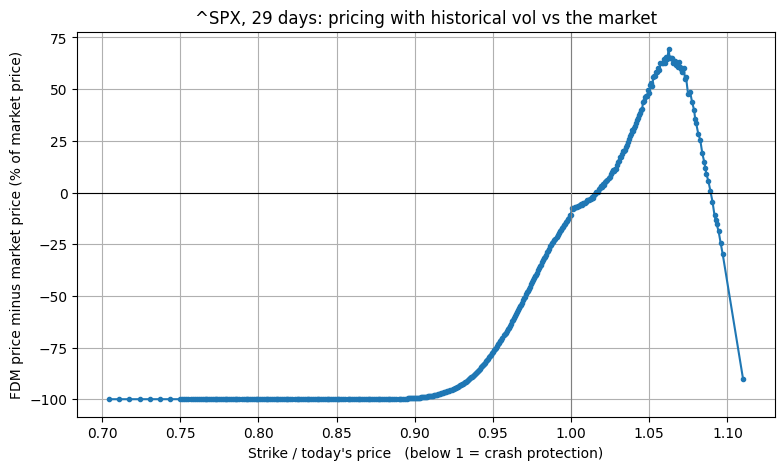

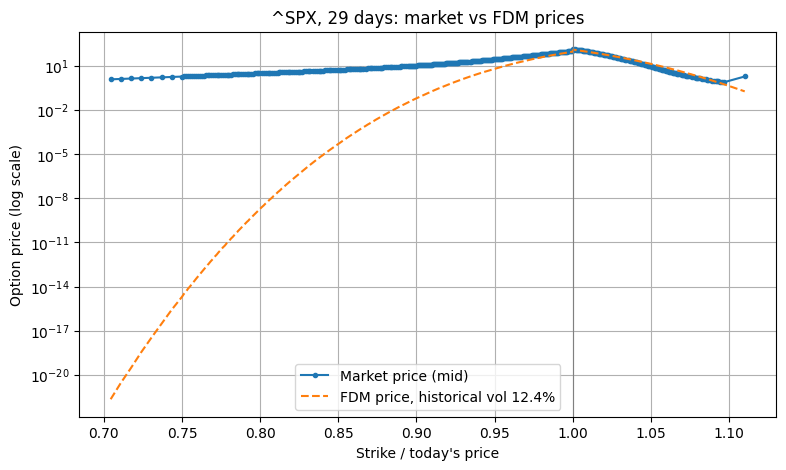

In [20]:
# -----------------------------
# 33. Main result: FDM price with historical vol vs the market price
# -----------------------------
# For the shortest maturity, price every out-of-the-money option with the FDM using
# 90-day historical volatility, and compare with what the market charges.
# As a check, also price each option with the FDM at its OWN implied vol:
# that should reproduce the market price (small differences = FDM grid error).

main_expiry = otm["expiry"].min()
main = otm[otm["expiry"] == main_expiry].sort_values("strike").copy()

# Drop options worth almost nothing: their price is mostly bid-ask noise,
# and percentage gaps on tiny prices blow up
MIN_PRICE = 0.0001 * S0_mkt
main = main[main["mid"] >= MIN_PRICE]
T_main = main["T"].iloc[0]
q_main = main["q"].iloc[0]

# Grid: S_max = 2 * S0 with M even, so today's price sits exactly on a grid point
S_max_mkt = 2 * S0_mkt
M_mkt = 800

fd_hist, fd_iv = [], []
for row in main.itertuples():
    p_hist, _, _ = finite_difference_price(S0_mkt, row.strike, S_max_mkt, M_mkt, T_main, 1,
                                           r_mkt, sigma_hist, row.type, q_main)
    p_iv, _, _ = finite_difference_price(S0_mkt, row.strike, S_max_mkt, M_mkt, T_main, 1,
                                         r_mkt, row.iv, row.type, q_main)
    fd_hist.append(p_hist)
    fd_iv.append(p_iv)

main["FDM price (hist vol)"] = fd_hist
main["FDM price (implied vol)"] = fd_iv
main["Gap vs market (%)"] = 100 * (main["FDM price (hist vol)"] - main["mid"]) / main["mid"]
main["FDM check error (%)"] = 100 * (main["FDM price (implied vol)"] - main["mid"]) / main["mid"]

days_main = int(round(T_main * 365))
print(f"{OPTION_TICKER}, {days_main}-day options, 90-day historical vol = {sigma_hist:.2%}")
print("Largest FDM check error at implied vol:",
      round(main["FDM check error (%)"].abs().max(), 3), "%")

# Summary table at a few chosen strikes
targets = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10]
picked = [(main["moneyness"] - m).abs().idxmin() for m in targets]
summary = main.loc[picked, ["type", "strike", "moneyness", "mid", "iv",
                            "FDM price (hist vol)", "Gap vs market (%)"]].drop_duplicates()
summary.columns = ["Type", "Strike", "Strike / S0", "Market price", "Implied vol",
                   "FDM price (hist vol)", "Gap vs market (%)"]
print("\nFDM with historical vol vs market, selected strikes:")
print(summary.round(4).to_string(index=False))

# Plot 1: the pricing gap across strikes
plt.figure(figsize=(9, 5))
plt.plot(main["moneyness"], main["Gap vs market (%)"], marker=".")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(1.0, color="grey", linewidth=0.8)
plt.xlabel("Strike / today's price   (below 1 = crash protection)")
plt.ylabel("FDM price minus market price (% of market price)")
plt.title(f"{OPTION_TICKER}, {days_main} days: pricing with historical vol vs the market")
plt.grid(True)
plt.show()

# Plot 2: the prices themselves
plt.figure(figsize=(9, 5))
plt.plot(main["moneyness"], main["mid"], marker=".", label="Market price (mid)")
plt.plot(main["moneyness"], main["FDM price (hist vol)"], linestyle="--",
         label=f"FDM price, historical vol {sigma_hist:.1%}")
plt.axvline(1.0, color="grey", linewidth=0.8)
plt.yscale("log")
plt.xlabel("Strike / today's price")
plt.ylabel("Option price (log scale)")
plt.title(f"{OPTION_TICKER}, {days_main} days: market vs FDM prices")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# -----------------------------
# 34. Hedging: delta of a crash put under historical vs implied vol
# -----------------------------
# Delta = how many units of the index to hold to offset the option's risk.
# Taken from the FDM grid exactly as in section 14.

crash_row = main.loc[(main["moneyness"] - 0.90).abs().idxmin()]   # put about 10% below today

def fd_delta(sigma):
    _, dS_d, _, S_d, _, V_d = finite_difference_price(
        S0_mkt, crash_row["strike"], S_max_mkt, M_mkt, T_main, 1,
        r_mkt, sigma, "put", q_main, return_grid=True)
    i0_d = int(round(S0_mkt / dS_d))
    return (V_d[i0_d + 1, 0] - V_d[i0_d - 1, 0]) / (2 * dS_d)

delta_hist = fd_delta(sigma_hist)
delta_iv = fd_delta(crash_row["iv"])

print(f"Crash put: strike {crash_row['strike']:.0f} "
      f"({crash_row['moneyness']:.1%} of today's price), {days_main} days")
print(f"  Market price: {crash_row['mid']:.2f}")
print(f"  Delta with historical vol ({sigma_hist:.1%}): {delta_hist:.4f}")
print(f"  Delta with implied vol    ({crash_row['iv']:.1%}): {delta_iv:.4f}")
if delta_iv != 0:
    print(f"  A seller hedging with historical vol holds {abs(delta_hist / delta_iv):.0%} "
          "of the hedge the market's own pricing implies.")


Crash put: strike 6900 (90.0% of today's price), 29 days
  Market price: 10.45
  Delta with historical vol (12.4%): -0.0008
  Delta with implied vol    (23.8%): -0.0477
  A seller hedging with historical vol holds 2% of the hedge the market's own pricing implies.
